In [1]:
!pip install pandas scikit-learn matplotlib seaborn joblib

In [2]:
import pandas as pd

df = pd.read_csv('mental_health_risk_dataset.csv')
print(df.shape)  # Should show ~ (409, 25) based on the data
print(df.head())
print(df['mental_health_risk'].value_counts())  # Check class distribution

(25000, 25)
   age  gender marital_status education_level employment_status  sleep_hours  \
0   56   Other         Single        Bachelor        Unemployed          8.6   
1   47    Male         Single        Bachelor        Unemployed          4.5   
2   56  Female       Divorced        Bachelor           Student          3.1   
3   59   Other        Married        Bachelor          Employed          7.0   
4   58    Male         Single     High School     Self-Employed          5.1   

   physical_activity_hours_per_week  screen_time_hours_per_day  \
0                               2.8                        9.6   
1                               2.7                        3.0   
2                              14.1                        7.2   
3                               0.5                       10.3   
4                               2.5                        1.2   

   social_support_score  work_stress_level  ...  depression_score  \
0                     7                 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# If you restarted runtime, reload
# df = pd.read_csv('mental_health_risk_dataset.csv')

print("Shape:", df.shape)
print("\nMissing values total:", df.isna().sum().sum())          # should be 0
print("Duplicate rows:", df.duplicated().sum())                 # should be 0
print("\nData types:\n", df.dtypes.value_counts())

Shape: (25000, 25)

Missing values total: 0
Duplicate rows: 0

Data types:
 int64      18
object      4
float64     3
Name: count, dtype: int64


/tmp/ipykernel_1491/4140143354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='mental_health_risk', palette='viridis')


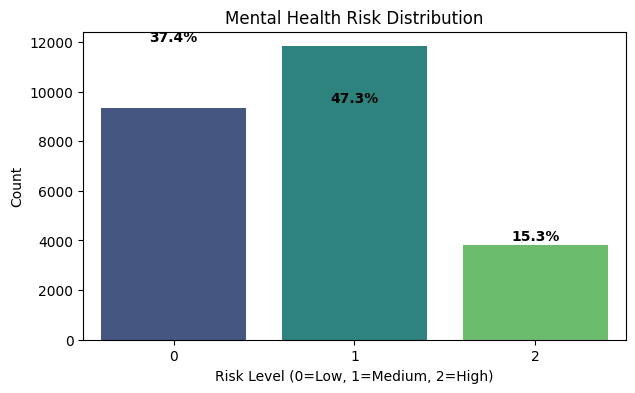

In [4]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='mental_health_risk', palette='viridis')
plt.title("Mental Health Risk Distribution")
plt.xlabel("Risk Level (0=Low, 1=Medium, 2=High)")
plt.ylabel("Count")

# Add percentage labels
counts = df['mental_health_risk'].value_counts()
percent = counts / len(df) * 100
for i, v in enumerate(counts):
    plt.text(i, v+200, f"{percent[i]:.1f}%", ha='center', fontweight='bold')

plt.show()

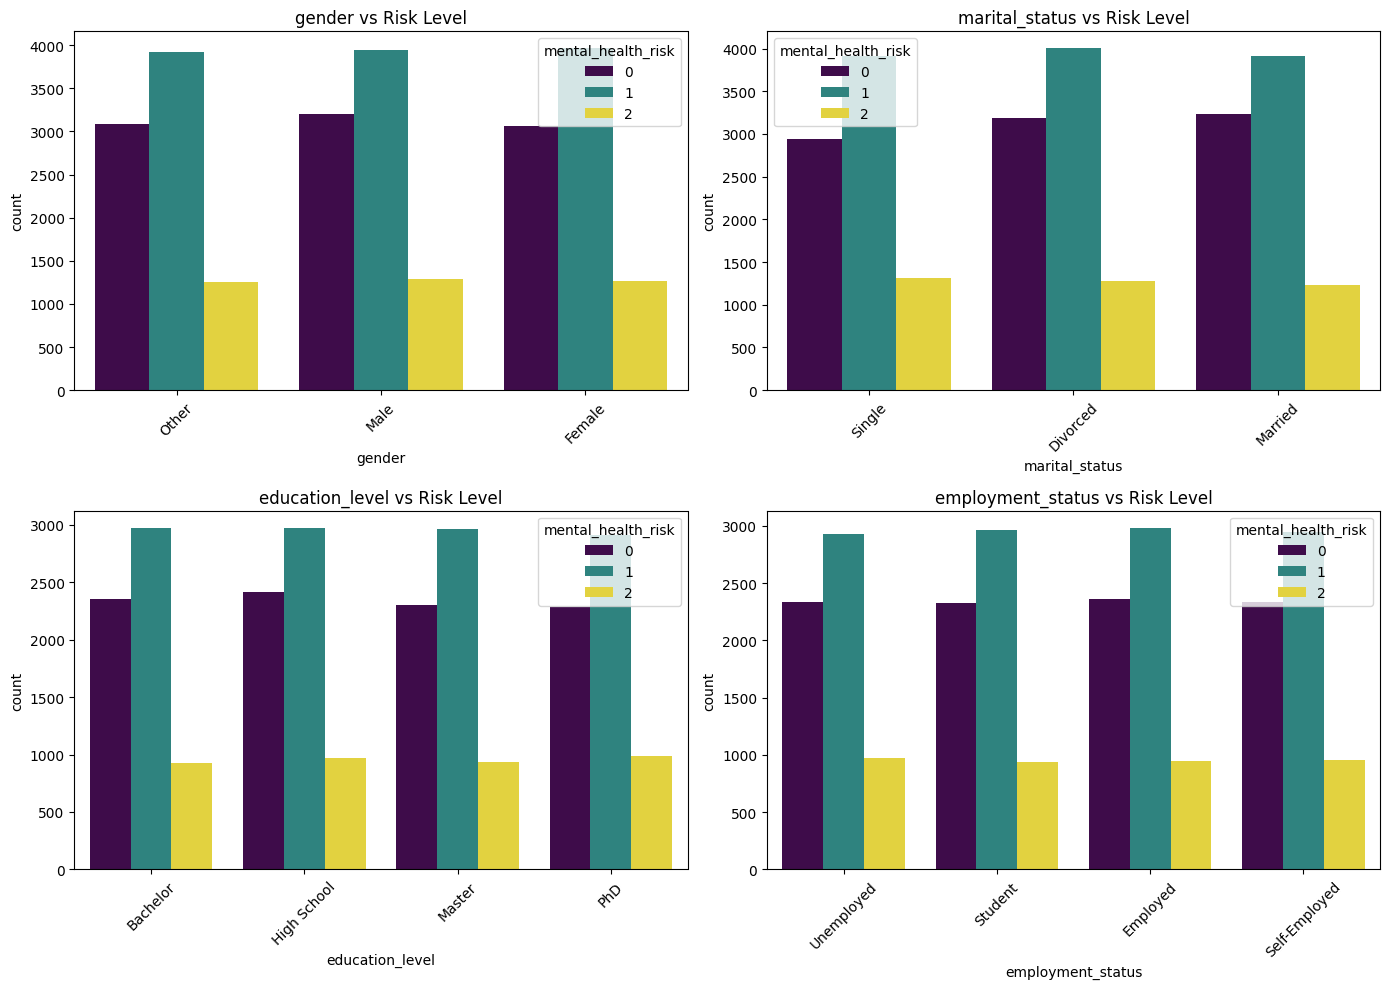

In [5]:
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='mental_health_risk', ax=axes[i], palette='viridis')
    axes[i].set_title(f"{col} vs Risk Level")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

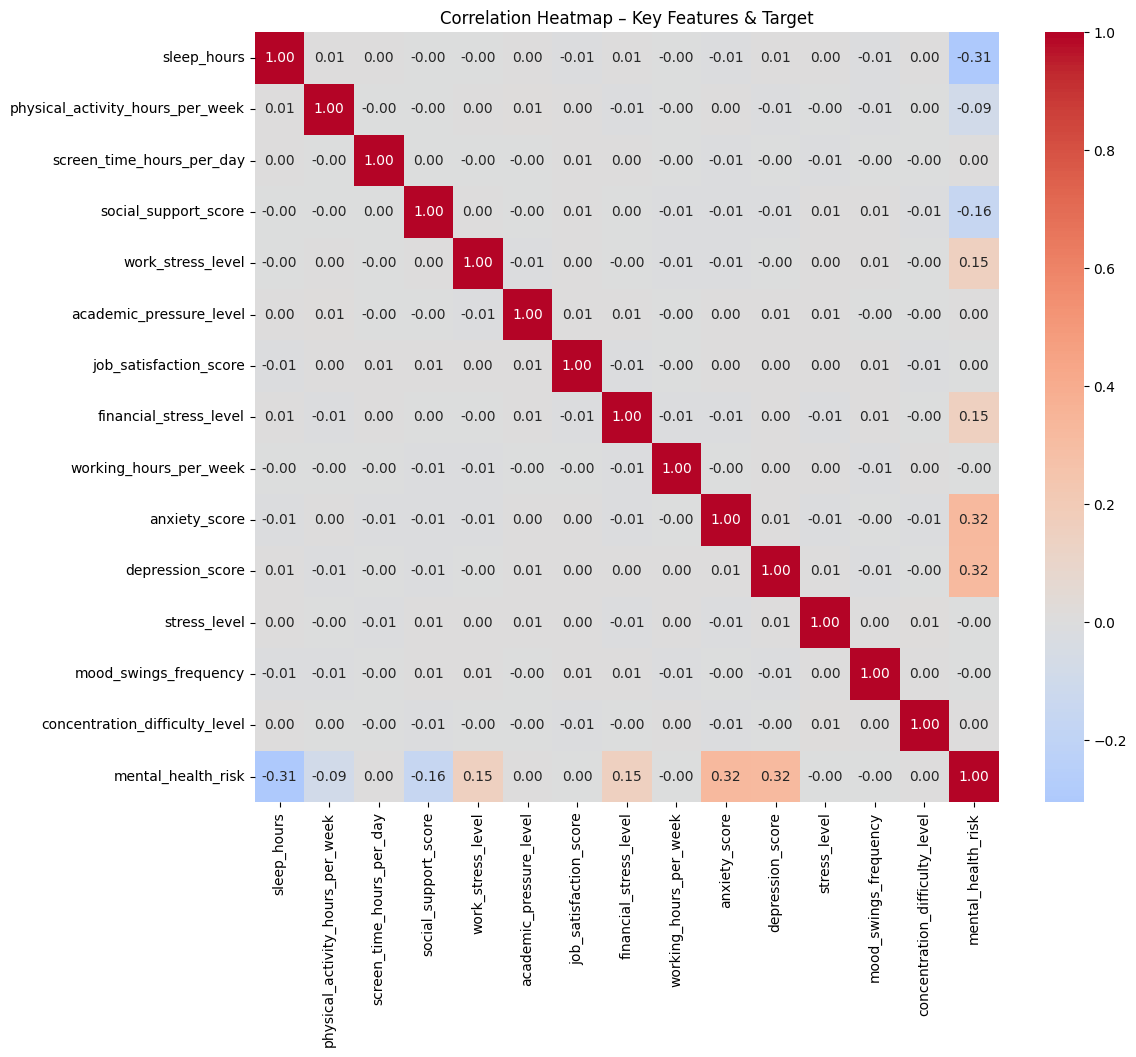

In [6]:
num_cols_related = [
    'sleep_hours', 'physical_activity_hours_per_week', 'screen_time_hours_per_day',
    'social_support_score', 'work_stress_level', 'academic_pressure_level',
    'job_satisfaction_score', 'financial_stress_level', 'working_hours_per_week',
    'anxiety_score', 'depression_score', 'stress_level',
    'mood_swings_frequency', 'concentration_difficulty_level'
]

corr = df[num_cols_related + ['mental_health_risk']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap – Key Features & Target")
plt.show()

/tmp/ipykernel_1491/2716486218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mental_health_risk', y=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1491/2716486218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mental_health_risk', y=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1491/2716486218.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mental_health_risk', y=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_1491/2716486218.py:7: FutureWarning: 

Passing `palette` without assig

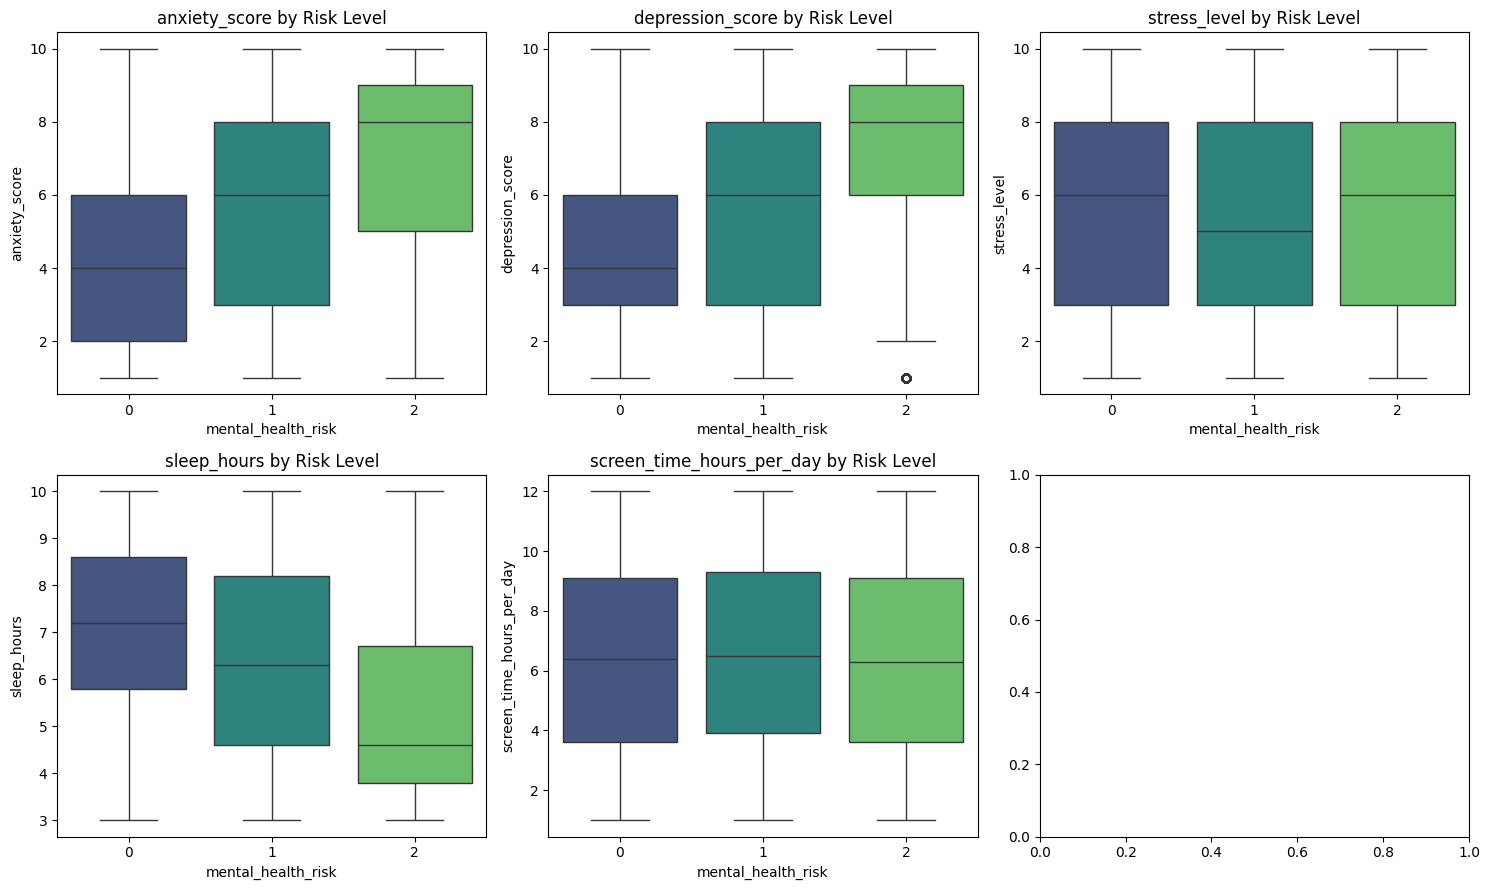

In [7]:
important_num = ['anxiety_score', 'depression_score', 'stress_level', 'sleep_hours', 'screen_time_hours_per_day']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for i, col in enumerate(important_num):
    sns.boxplot(data=df, x='mental_health_risk', y=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f"{col} by Risk Level")

plt.tight_layout()
plt.show()

In [8]:
# Target
target = 'mental_health_risk'

# Categorical (nominal) - need one-hot or target encoding later
categorical_cols = ['gender', 'marital_status', 'education_level', 'employment_status']

# Binary (already 0/1) - good as-is
binary_cols = [
    'panic_attack_history', 'family_history_mental_illness',
    'previous_mental_health_diagnosis', 'therapy_history', 'substance_use'
]

# Numerical (continuous or ordinal scales 1-10 mostly)
numerical_cols = [
    'age', 'sleep_hours', 'physical_activity_hours_per_week', 'screen_time_hours_per_day',
    'social_support_score', 'work_stress_level', 'academic_pressure_level',
    'job_satisfaction_score', 'financial_stress_level', 'working_hours_per_week',
    'anxiety_score', 'depression_score', 'stress_level',
    'mood_swings_frequency', 'concentration_difficulty_level'
]

# Quick check
print("Categorical:", len(categorical_cols))
print("Binary:", len(binary_cols))
print("Numerical:", len(numerical_cols))
print("Total features:", len(categorical_cols) + len(binary_cols) + len(numerical_cols))

Categorical: 4
Binary: 5
Numerical: 15
Total features: 24


In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# We'll create preprocessor later, but for now see cardinality
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values → {df[col].value_counts().index.tolist()}")

gender: 3 unique values → ['Male', 'Female', 'Other']
marital_status: 3 unique values → ['Divorced', 'Married', 'Single']
education_level: 4 unique values → ['High School', 'Bachelor', 'Master', 'PhD']
employment_status: 4 unique values → ['Employed', 'Self-Employed', 'Unemployed', 'Student']


In [10]:
# 1. Total "negative load" score (higher = worse)
df['negative_load'] = (
    df['work_stress_level'] +
    df['academic_pressure_level'] +
    df['financial_stress_level'] +
    df['anxiety_score'] +
    df['depression_score'] +
    df['stress_level'] +
    df['mood_swings_frequency'] +
    df['concentration_difficulty_level']
) / 8.0   # average

# 2. Positive protective factors (higher = better)
df['protective_factors'] = (
    df['social_support_score'] +
    df['job_satisfaction_score'] +
    (10 - df['screen_time_hours_per_day'].clip(0,10))   # inverse screen time effect
) / 3.0

# 3. Sleep quality proxy (assuming 7-9 ideal)
df['sleep_quality'] = np.where(
    df['sleep_hours'].between(7, 9), 1,
    np.where(df['sleep_hours'] < 6, -1, 0)
)

# 4. Work-life imbalance rough proxy
df['work_life_imbalance'] = df['working_hours_per_week'] / 40.0 - 1.0   # >40 → positive (bad)

print("New engineered features added. New shape:", df.shape)

New engineered features added. New shape: (25000, 29)


In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape: ", X_test.shape,  y_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts(normalize=True).round(3))

Train shape: (20000, 28) (20000,)
Test shape:  (5000, 28) (5000,)

Train class distribution:
 mental_health_risk
1    0.473
0    0.374
2    0.153
Name: proportion, dtype: float64


In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Update feature lists (include new engineered ones)
numerical_features = numerical_cols + ['negative_load', 'protective_factors', 'sleep_quality', 'work_life_imbalance']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),  # just in case
            ('scaler', StandardScaler())
        ]), numerical_features),

        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_cols),

        ('bin', 'passthrough', binary_cols)   # already 0/1
    ])

print("Preprocessor ready.")

Preprocessor ready.


In [13]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)

    print(f"\n=== {model_name} Results ===")
    print(classification_report(y_test, y_pred, digits=3, target_names=['Low', 'Medium', 'High']))

    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"Macro F1: {macro_f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


=== Random Forest Results ===
              precision    recall  f1-score   support

         Low      0.982     0.995     0.989      1871
      Medium      0.946     0.971     0.958      2365
        High      0.948     0.840     0.891       764

    accuracy                          0.960      5000
   macro avg      0.959     0.935     0.946      5000
weighted avg      0.960     0.960     0.959      5000

Macro F1: 0.9460


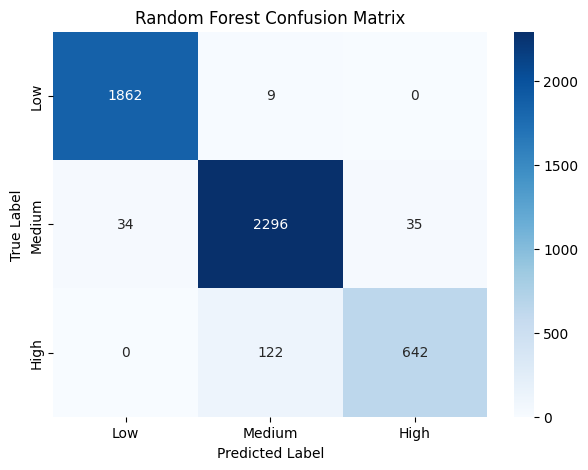

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)
evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")


=== Random Forest Results ===
              precision    recall  f1-score   support

         Low      0.982     0.995     0.989      1871
      Medium      0.946     0.971     0.958      2365
        High      0.948     0.840     0.891       764

    accuracy                          0.960      5000
   macro avg      0.959     0.935     0.946      5000
weighted avg      0.960     0.960     0.959      5000

Macro F1: 0.9460


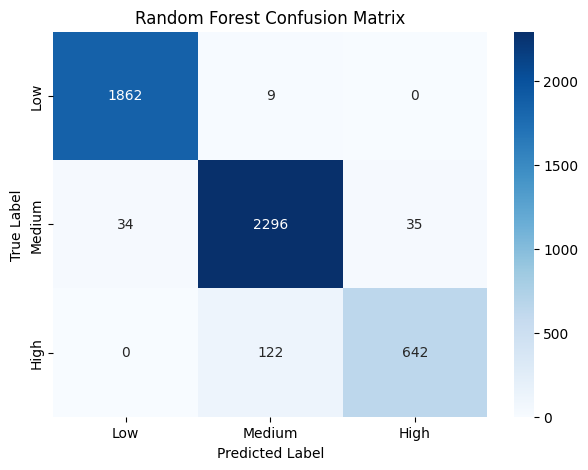

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

rf_pipeline.fit(X_train, y_train)
evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== LightGBM Results ===
              precision    recall  f1-score   support

         Low      0.999     1.000     0.999      1871
      Medium      0.997     0.999     0.998      2365
        High      0.999     0.990     0.994       764

    accuracy                          0.998      5000
   macro avg      0.998     0.996     0.997      5000
weighted avg      0.998     0.998     0.998      5000

Macro F1: 0.9971


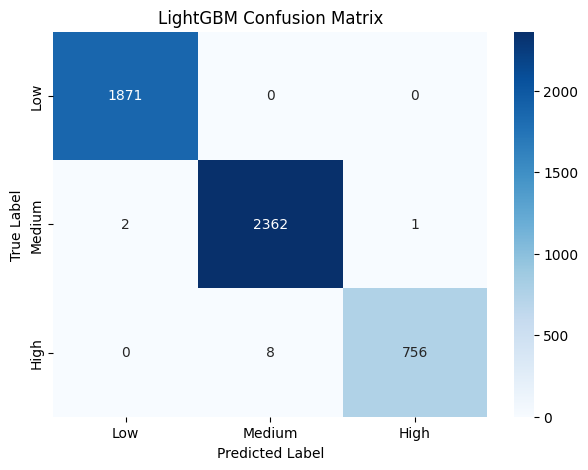

In [16]:
import lightgbm as lgb

lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.06,
        max_depth=8,
        num_leaves=50,
        subsample=0.9,
        colsample_bytree=0.7,
        random_state=42,
        class_weight='balanced',
        verbose=-1
    ))
])

lgb_pipeline.fit(X_train, y_train)
evaluate_model(lgb_pipeline, X_test, y_test, "LightGBM")

Total output features: 34
First 10: ['age', 'sleep_hours', 'physical_activity_hours_per_week', 'screen_time_hours_per_day', 'social_support_score', 'work_stress_level', 'academic_pressure_level', 'job_satisfaction_score', 'financial_stress_level', 'working_hours_per_week']
Last 10: ['education_level_Master', 'education_level_PhD', 'employment_status_Self-Employed', 'employment_status_Student', 'employment_status_Unemployed', 'panic_attack_history', 'family_history_mental_illness', 'previous_mental_health_diagnosis', 'therapy_history', 'substance_use']


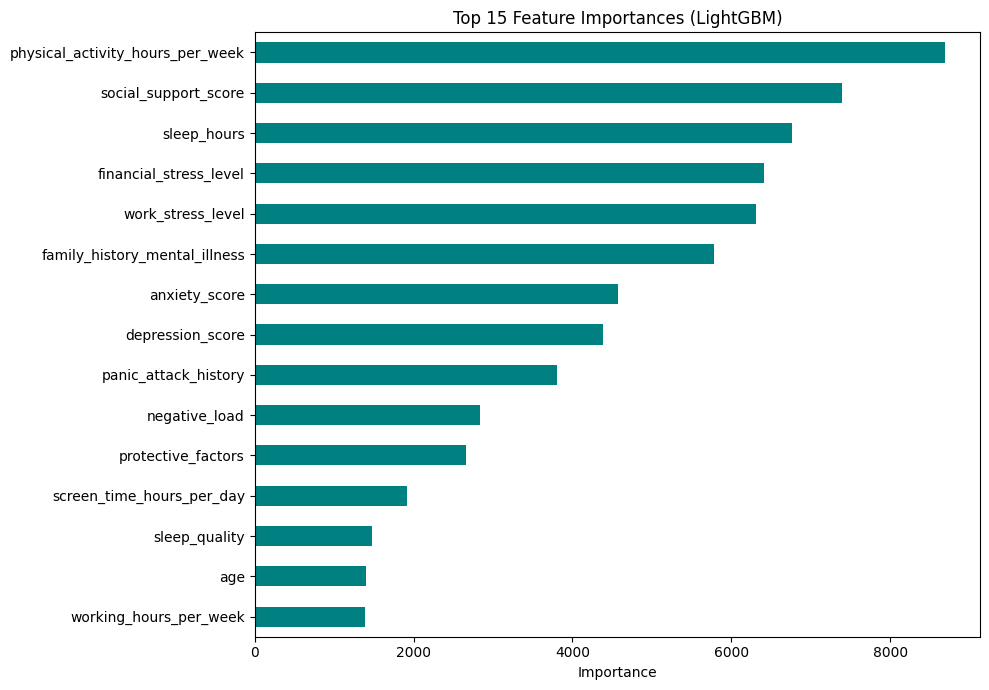


Top 10 most important features:
physical_activity_hours_per_week    8695
social_support_score                7398
sleep_hours                         6759
financial_stress_level              6417
work_stress_level                   6316
family_history_mental_illness       5786
anxiety_score                       4576
depression_score                    4380
panic_attack_history                3803
negative_load                       2834
dtype: int32


In [18]:
# ────────────────────────────────────────────────
# Correct way to get ALL feature names after transformation
# ────────────────────────────────────────────────

# Fit the preprocessor once to get the real column names
preprocessor.fit(X_train)   # ← important!

# Get numerical feature names (they stay the same)
num_features_out = numerical_features

# Get one-hot feature names
cat_features_out = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Binary features stay the same
bin_features_out = binary_cols

# Combine ALL output feature names in correct order
all_feature_names = (
    list(num_features_out) +
    list(cat_features_out) +
    list(bin_features_out)
)

print("Total output features:", len(all_feature_names))
print("First 10:", all_feature_names[:10])
print("Last 10:", all_feature_names[-10:])

# Now extract importances from the BEST model
# (change lgb_pipeline → xgb_pipeline or rf_pipeline if you prefer that model)
best_model = lgb_pipeline.named_steps['classifier']          # ← or xgb_pipeline / rf_pipeline

importances = pd.Series(
    best_model.feature_importances_,
    index=all_feature_names
)

# Plot top features
plt.figure(figsize=(10, 7))
importances.sort_values(ascending=True).tail(15).plot(kind='barh', color='teal')
plt.title("Top 15 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Optional: print top 10 numerically
print("\nTop 10 most important features:")
print(importances.sort_values(ascending=False).head(10).round(4))

In [19]:
!pip install optuna shap -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 5.1 MB/s eta 0:00:00


In [20]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10.0),
        'random_state': 42,
        'class_weight': 'balanced',
        'verbose': -1
    }

    model = LGBMClassifier(**params)

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Use cross-validation macro F1
    macro_f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring=macro_f1_scorer, n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)  # increase to 50–100 if you have time

print("Best params:", study.best_params)
print("Best macro F1 (CV):", study.best_value)

[I 2026-03-03 17:33:14,641] A new study created in memory with name: no-name-9a1897b8-f64b-4dfd-9626-8f6b2d43fa11
[I 2026-03-03 17:33:51,011] Trial 0 finished with value: 0.9959304724856619 and parameters: {'n_estimators': 277, 'learning_rate': 0.08807392781624272, 'max_depth': 12, 'num_leaves': 72, 'min_child_samples': 44, 'subsample': 0.7495367603532995, 'colsample_bytree': 0.6074415991902836, 'reg_alpha': 9.371963857016981, 'reg_lambda': 7.255871637037236}. Best is trial 0 with value: 0.9959304724856619.
[I 2026-03-03 17:34:09,794] Trial 1 finished with value: 0.9953183341720477 and parameters: {'n_estimators': 306, 'learning_rate': 0.06501556251746476, 'max_depth': 8, 'num_leaves': 39, 'min_child_samples': 73, 'subsample': 0.8842614452680669, 'colsample_bytree': 0.8847874021596702, 'reg_alpha': 8.01468049337107, 'reg_lambda': 4.118449580779653}. Best is trial 0 with value: 0.9959304724856619.
[I 2026-03-03 17:34:28,015] Trial 2 finished with value: 0.9930158520210176 and parameters

Best params: {'n_estimators': 601, 'learning_rate': 0.1911110694707525, 'max_depth': 8, 'num_leaves': 21, 'min_child_samples': 73, 'subsample': 0.6697907318178461, 'colsample_bytree': 0.6552329158878177, 'reg_alpha': 1.5782284806902664, 'reg_lambda': 2.1118870927962266}
Best macro F1 (CV): 0.9990525737620303


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Tuned LightGBM Results ===
              precision    recall  f1-score   support

         Low      1.000     1.000     1.000      1871
      Medium      0.998     1.000     0.999      2365
        High      1.000     0.995     0.997       764

    accuracy                          0.999      5000
   macro avg      0.999     0.998     0.999      5000
weighted avg      0.999     0.999     0.999      5000

Macro F1: 0.9988


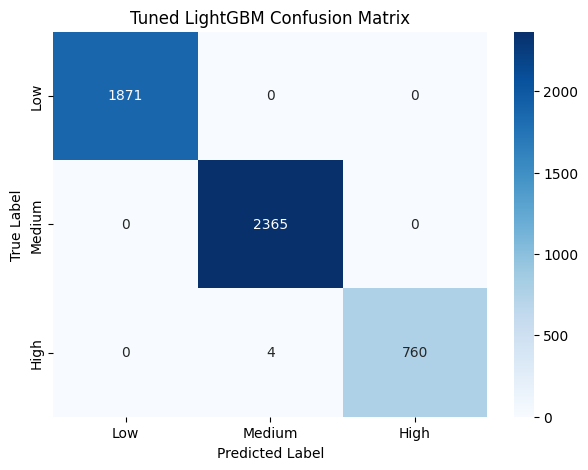

In [21]:
best_params = study.best_params

final_lgb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        **best_params,
        random_state=42,
        class_weight='balanced',
        verbose=-1
    ))
])

final_lgb.fit(X_train, y_train)
evaluate_model(final_lgb, X_test, y_test, "Tuned LightGBM")

In [24]:
# ────────────────────────────────────────────────
# SHAP shape debug – run this cell
# ────────────────────────────────────────────────

print("X_test_transformed shape:", X_test_transformed.shape)
print("Number of features expected:", X_test_transformed.shape[1])

print("\nall_feature_names length:", len(all_feature_names))
print("First 5 feature names:", all_feature_names[:5])
print("Last 5 feature names:", all_feature_names[-5:])

print("\nType of shap_values:", type(shap_values))
print("Length of shap_values list:", len(shap_values))  # should be 3

if isinstance(shap_values, list):
    for i in range(len(shap_values)):
        print(f"shap_values[{i}].shape:", shap_values[i].shape)
else:
    print("shap_values.shape:", shap_values.shape)

# Quick consistency check
expected_cols = X_test_transformed.shape[1]
if all(sv.shape[1] == expected_cols for sv in shap_values):
    print("\n→ Shapes match! You can proceed with summary_plot.")
else:
    print("\n→ MISMATCH DETECTED! Do NOT run summary_plot yet.")

X_test_transformed shape: (5000, 34)
Number of features expected: 34

all_feature_names length: 34
First 5 feature names: ['age', 'sleep_hours', 'physical_activity_hours_per_week', 'screen_time_hours_per_day', 'social_support_score']
Last 5 feature names: ['panic_attack_history', 'family_history_mental_illness', 'previous_mental_health_diagnosis', 'therapy_history', 'substance_use']

Type of shap_values: <class 'numpy.ndarray'>
Length of shap_values list: 5000
shap_values.shape: (5000, 34, 3)

→ MISMATCH DETECTED! Do NOT run summary_plot yet.


In [25]:
# Re-fit preprocessor on train (just in case)
preprocessor.fit(X_train)

# Get output feature names properly
num_out = numerical_features
cat_out = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
bin_out = binary_cols

all_feature_names = list(num_out) + list(cat_out) + list(bin_out)

print("Re-created all_feature_names length:", len(all_feature_names))

Re-created all_feature_names length: 34


In [26]:
# Re-compute SHAP (this is safe – usually takes 1–4 minutes)
explainer = shap.TreeExplainer(final_lgb.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

print("Re-computed shap_values shapes:")
for i, sv in enumerate(shap_values):
    print(f"Class {i}: {sv.shape}")

Re-computed shap_values shapes:
Class 0: (34, 3)
Class 1: (34, 3)
Class 2: (34, 3)
Class 3: (34, 3)
Class 4: (34, 3)
Class 5: (34, 3)
Class 6: (34, 3)
Class 7: (34, 3)
Class 8: (34, 3)
Class 9: (34, 3)
Class 10: (34, 3)
Class 11: (34, 3)
Class 12: (34, 3)
Class 13: (34, 3)
Class 14: (34, 3)
Class 15: (34, 3)
Class 16: (34, 3)
Class 17: (34, 3)
Class 18: (34, 3)
Class 19: (34, 3)
Class 20: (34, 3)
Class 21: (34, 3)
Class 22: (34, 3)
Class 23: (34, 3)
Class 24: (34, 3)
Class 25: (34, 3)
Class 26: (34, 3)
Class 27: (34, 3)
Class 28: (34, 3)
Class 29: (34, 3)
Class 30: (34, 3)
Class 31: (34, 3)
Class 32: (34, 3)
Class 33: (34, 3)
Class 34: (34, 3)
Class 35: (34, 3)
Class 36: (34, 3)
Class 37: (34, 3)
Class 38: (34, 3)
Class 39: (34, 3)
Class 40: (34, 3)
Class 41: (34, 3)
Class 42: (34, 3)
Class 43: (34, 3)
Class 44: (34, 3)
Class 45: (34, 3)
Class 46: (34, 3)
Class 47: (34, 3)
Class 48: (34, 3)
Class 49: (34, 3)
Class 50: (34, 3)
Class 51: (34, 3)
Class 52: (34, 3)
Class 53: (34, 3)
Class 

In [27]:
import joblib
import json
import os

# 1. Save the full pipeline (preprocessor + tuned model)
joblib.dump(final_lgb, 'psyche_risk_model_full.joblib')
print("Full pipeline saved: psyche_risk_model_full.joblib")

# 2. Save feature names list (very useful for inference / Gradio)
with open('feature_names.json', 'w') as f:
    json.dump(all_feature_names, f, indent=2)
print("Feature names saved: feature_names.json")

# 3. Save best params (for documentation / reproducibility)
with open('best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)
print("Best hyperparameters saved: best_params.json")

# 4. Optional: save a small sample of test data for demo/testing
X_test_sample = X_test.head(20).to_json(orient='records', indent=2)
with open('test_sample.json', 'w') as f:
    f.write(X_test_sample)
print("Sample test inputs saved: test_sample.json")

Full pipeline saved: psyche_risk_model_full.joblib
Feature names saved: feature_names.json
Best hyperparameters saved: best_params.json
Sample test inputs saved: test_sample.json
